In [1]:
from pytential.sympy_pytential import sympy_pytential
from pytential.reduce import min_pytential
import numpy as np
from sympy import log, symbols
import matplotlib.pyplot as plt

This file demonstrates how to create, combine, and manipulate pytentials.  Equibilriation is used to reduce free variables. 

# Create phases

In [2]:
xa, xb, x = symbols('xa xb x')

In [3]:
RT = 8.134*300
fa_sp = xa*RT*(1+log(xa)) +(1-xa)*RT*log(1-xa)
fb_sp = xb*RT*log(xb) +(1-xb)*RT*(1+log(1-xb))

In [4]:
fa = sympy_pytential(fa_sp)
fb = sympy_pytential(fb_sp)
print('fa:', fa)

fa: x = ['xa']

f(x) = 2440.2*xa*(log(xa) + 1) + (2440.2 - 2440.2*xa)*log(1 - xa)

f'(x)= [2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2]

f"(x)= [[-2440.2/(xa*(xa - 1))]]


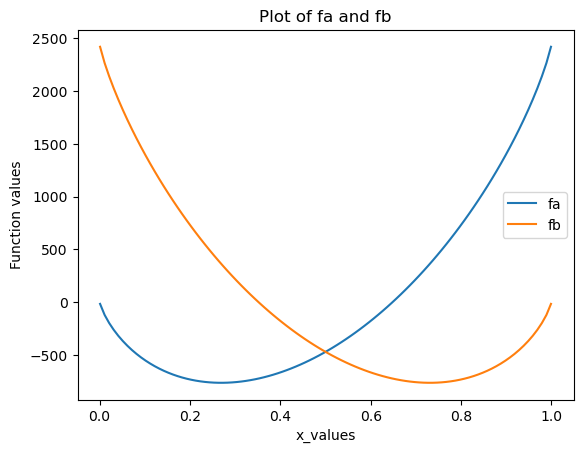

In [5]:
x_values = np.linspace(0.001, .999, 100);
ya = fa(xa=x_values)
yb = fb(xb=x_values)

plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.xlabel('x_values')
plt.ylabel('Function values')
plt.title('Plot of fa and fb')
plt.legend()
plt.show()

# Combine functions

Combine functions into a composite pytential

In [6]:
f = fa+fb
print(f)

x = ['xa', 'xb']

f(x) = 2440.2*xa*(log(xa) + 1) + 2440.2*xb*log(xb) + (2440.2 - 2440.2*xa)*log(1 - xa) + (2440.2 - 2440.2*xb)*(log(1 - xb) + 1)

f'(x)= [2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2, 2440.2*log(xb) - 2440.2*log(1 - xb) - 2440.2]

f"(x)= [[-2440.2/(xa*(xa - 1)), 0], [0, -2440.2/(xb*(xb - 1))]]


Add a constraint for the total x. Note the function is now an argument of x1, x2, and x

In [7]:
f_constrained = f.add_constraints_sym([xa+xb-x])
print(f_constrained)

x = ['x', 'xa', 'xb']

f(x) = 2440.2*xa*(log(xa) + 1) + 2440.2*xb*log(xb) + (2440.2 - 2440.2*xa)*log(1 - xa) + (2440.2 - 2440.2*xb)*(log(1 - xb) + 1)

f'(x)= [0, 2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2, 2440.2*log(xb) - 2440.2*log(1 - xb) - 2440.2]

f"(x)= [[0, 0, 0], [0, -2440.2/(xa*(xa - 1)), 0], [0, 0, -2440.2/(xb*(xb - 1))]]

Constraints:
0 = -x + xa + xb



In [8]:
print(f_constrained.constraints)


[<function _lambdifygenerated at 0x7220d5a4ba60>]


In [9]:
f_min = min_pytential(f_constrained, 'x')
x_values = np.linspace(0.001, .999, 10)
[f_min([i]) for i in x_values]
print(f_min.min_fcn([.3]))

pyt_reduced x = ['xa', 'xb']

f(x) = 2440.2*xa*(log(xa) + 1) + 2440.2*xb*log(xb) + (2440.2 - 2440.2*xa)*log(1 - xa) + (2440.2 - 2440.2*xb)*(log(1 - xb) + 1)

f'(x)= [2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2, 2440.2*log(xb) - 2440.2*log(1 - xb) - 2440.2]

f"(x)= [[-2440.2/(xa*(xa - 1)), 0], [0, -2440.2/(xb*(xb - 1))]]

Constraints:
0 = xa + xb - 0.001

pyt_reduced x = ['xa', 'xb']

f(x) = 2440.2*xa*(log(xa) + 1) + 2440.2*xb*log(xb) + (2440.2 - 2440.2*xa)*log(1 - xa) + (2440.2 - 2440.2*xb)*(log(1 - xb) + 1)

f'(x)= [2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2, 2440.2*log(xb) - 2440.2*log(1 - xb) - 2440.2]

f"(x)= [[-2440.2/(xa*(xa - 1)), 0], [0, -2440.2/(xb*(xb - 1))]]

Constraints:
0 = xa + xb - 0.111888888888889

pyt_reduced x = ['xa', 'xb']

f(x) = 2440.2*xa*(log(xa) + 1) + 2440.2*xb*log(xb) + (2440.2 - 2440.2*xa)*log(1 - xa) + (2440.2 - 2440.2*xb)*(log(1 - xb) + 1)

f'(x)= [2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2, 2440.2*log(xb) - 2440.2*log(1 - xb) - 2440.2]

f"(x)= [[-244